In [7]:
from glob import glob
from pathlib import Path
import pickle

import matplotlib
#matplotlib.use('Qt5Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from model_tuner.opt.regimes import NetRegime1D, NetRegime1DList
from model_tuner.opt.uc_mappers import NetUCMapper1D

from model_tuner.main import (
    UCMapFitParams,
    init_uc_mapper,
    plot_opt_iteration_pop
)

from model_tuner.utils import load_yaml

In [10]:
dirpath_base = Path(
    r'D:\WORK\Salvador\repo\model_tuner\opt_experiments\ou_surr_to_full'
    r'\data\exp_subnet_state1_mech1_nosub_wmult_0.1'
)

exp_name = 'L4_conn_5s_richards_c_0_0.1'

# Load UC params
fpath_uc_params = dirpath_base / exp_name / 'uc_map_params.yaml'
uc_map_params: UCMapFitParams = load_yaml(fpath_uc_params,
                                          data_class=UCMapFitParams)

# Load target firing rates
df_target_rates = pd.read_csv(dirpath_base / 'target_state_1.csv')
target_rates = dict(zip(df_target_rates['pop_name'],
                        df_target_rates['target_rate']))

fpath_mask = str(dirpath_base / exp_name / 'info' / 'Ru_Rc_req_*.pkl')
n_iter = len(glob(fpath_mask))

# Load Ru and Rc matrices
iter_data = {}
for n in range(1, n_iter + 1):
    fpath_iter_data = dirpath_base / exp_name / 'info' / f'Ru_Rc_req_{n}_3.pkl'
    with open(fpath_iter_data, 'rb') as f:
        iter_data[n] = pickle.load(f)

# Ru and Rc regime lists from matrices
pop_names = uc_map_params.pop_names
Ru_lst, Rc_lst = {}, {}
for n in range(1, n_iter + 1):
    Ru_lst[n] = NetRegime1DList.from_regimes_mat(
        pop_names, iter_data[n]['Ru'].isel(iter=-1))
    Rc_lst[n] = NetRegime1DList.from_regimes_mat(
        pop_names, iter_data[n]['Rc'].isel(iter=-1))

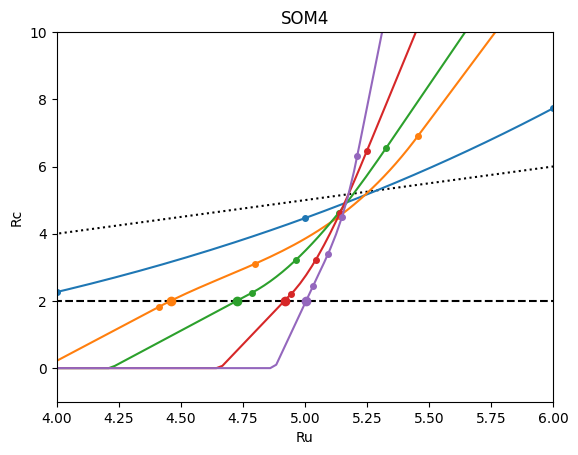

In [23]:
# Change U-C mapping parameters
uc_map_params.map_type = 'spline'
uc_map_params.map_fit_params.verbose = 0
uc_map_params.map_fit_params.ftol = 1e-4
#uc_map_params.map_fit_params.gtol = 1e-10
#uc_map_params.map_fit_params.max_nfev = 10000
uc_map_params.map_fit_params.return_first_guess = 0
uc_map_params.fit_param_bounds = {}
#uc_map_params.fit_param_bounds['y0'] = (0, 0.1)
#uc_map_params.fit_param_bounds['c'] = (0, 0.1)

pop_name_vis = 'SOM4'
#pop_name_vis = 'PV4'

plt.figure()
#plt.ion()

pop_id_vis = pop_names.index(pop_name_vis)
vmin = iter_data[n]['Ru'][pop_id_vis, :].min() * 0.8
vmax = iter_data[n]['Ru'][pop_id_vis, :].max() * 1.2
#vmin = np.minimum(0, vmin)
#vmax = np.maximum(7, vmax)
plt.plot([vmin, vmax], [vmin, vmax], 'k:')

#rc_0 = target_rates[pop_name_vis]
rc_0 = 2
plt.plot([vmin, vmax], [rc_0, rc_0], 'k--')

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for k in range(1, n_iter + 1):
    # Fit U-C mapping
    uc_mapper = init_uc_mapper(uc_map_params)
    uc_fit_res = uc_mapper.fit_from_data(
        Ru_lst[k], Rc_lst[k], uc_map_params.map_fit_params,
        bounds=uc_map_params.fit_param_bounds,
        verbose=0
    )
    # Plot U-C mapping
    plot_opt_iteration_pop(
        pop_names, pop_name_vis, uc_mapper,
        Ru_lst[k], Rc_lst[k], color=colors[k - 1],
        ru_limits=(vmin, vmax)
    )
    # Inverse
    ru_0 = uc_mapper.pop_UC_mappers[pop_name_vis].Rc_to_Ru(rc_0).value
    plt.plot(ru_0, rc_0, 'o', color=colors[k - 1])

plt.xlim(4, 6)
plt.ylim(-1, 10)

plt.show()
#plt.draw()

#input('Press any key to continue...')


In [20]:
ru_0 = uc_mapper.pop_UC_mappers[pop_name_vis].Rc_to_Ru(rc_0)

d:\work\salvador\repo\model_tuner\model_tuner\opt\map_funcs\map_func_1d.py:170: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(


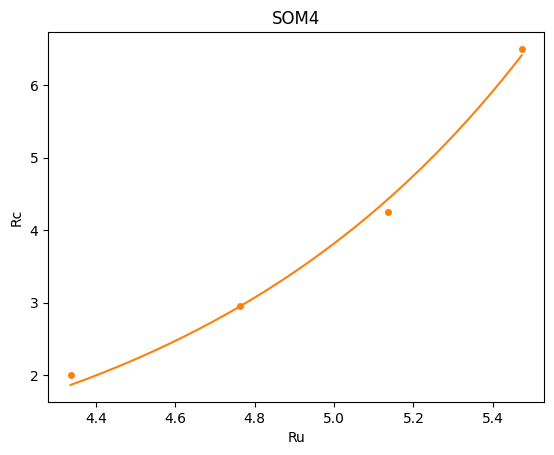

In [ ]:
k = 2
pop = 'SOM4'

uc_map_params.map_fit_params.verbose = 0
uc_map_params.map_fit_params.ftol = 1e-4
#uc_map_params.map_fit_params.gtol = 1e-10
uc_map_params.map_fit_params.return_first_guess = 0
#uc_map_params.fit_param_bounds['y0'] = (0, 0.1)
#uc_map_params.fit_param_bounds['c'] = (0, 0.1)

uc_mapper = init_uc_mapper(uc_map_params)
uc_mapper.pop_UC_mappers[pop].fit_from_data(
    Ru_lst[k].to_xr().sel(pop=pop).values,
    Rc_lst[k].to_xr().sel(pop=pop).values,
    uc_map_params.map_fit_params,
    bounds=uc_map_params.fit_param_bounds,
)
# Plot U-C mapping
plot_opt_iteration_pop(
    pop_names, pop, uc_mapper,
    Ru_lst[k], Rc_lst[k], color=colors[k - 1]
)

In [12]:
uc_mapper.pop_UC_mappers['SOM4']._map_func.__dict__

{'par': {'a': 12.534861218413974,
  'b': 5.5,
  'c': -0.07458536413002814,
  'k': 1.0150485446217319,
  'q': 1},
 '_x_limits': [0, inf],
 '_y_limits': [0, inf]}

In [3]:
import pickle 
fpath_in = (r'D:\WORK\Salvador\repo\model_tuner\opt_experiments\ou_surr_to_full'
            r'\data\exp_subnet_state1_mech1_nosub_wmult_0.1'
            r'\L4_conn_5s_richards_c_0_0.1\info\Ru_Rc_req_5_3.pkl')
with open(fpath_in, 'rb') as f:
    iter_data = pickle.load(f)

Text(0.5, 1.0, 'SOM4, iter=2')

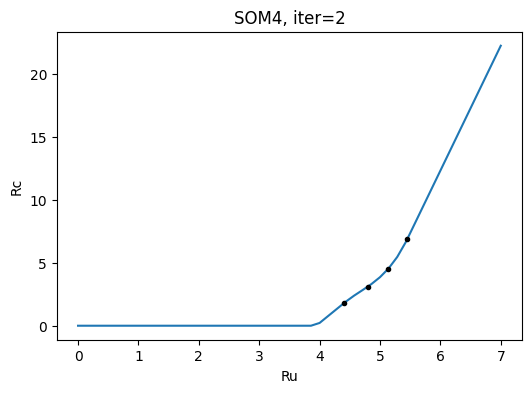

In [23]:
from scipy.interpolate import CubicSpline

iter = 2
pop = 'SOM4'
ru = iter_data['Ru'].sel(iter=iter, pop=pop).values
rc = iter_data['Rc'].sel(iter=iter, pop=pop).values

idx = np.argsort(ru)
ru, rc = ru[idx], rc[idx]

spline = CubicSpline(ru, rc, extrapolate=False)

def f(ru_):
    ru_ = np.asarray(ru_)
    rc_ = np.zeros_like(ru_)
    mask_l = ru_ < ru[0]
    mask_r = ru_ > ru[-1]
    mask_m = (ru[0] <= ru_) & (ru_ <= ru[-1])
    rc_[mask_l] = rc[0] + spline(ru[0], 1) * (ru_[mask_l] - ru[0])
    rc_[mask_r] = rc[-1] + spline(ru[-1], 1) * (ru_[mask_r] - ru[-1])
    rc_[mask_m] = spline(ru_[mask_m])
    if np.isscalar(ru_):
        rc_ = rc_[0]
    return rc_

ru_ = np.linspace(0, 7)
rc_ = f(ru_).clip(0, None)

plt.figure(figsize=(6, 4))
plt.plot(ru_, rc_)
plt.plot(ru, rc, 'k.')
plt.xlabel('Ru')
plt.ylabel('Rc')
plt.title(f'{pop}, iter={iter}')